In [1]:
from pathlib import Path

import pandas as pd


# ==========================================
# CONFIGURACIÓN
# ==========================================

BASE_DIR = Path.cwd()

DATASET_PATH = (
    BASE_DIR
    / "dataset_asistencia_nuevo.csv"
)

TARGET_COLUMN = "inasistencia_cita"

FEATURE_COLUMNS = [
    "age",
    "appointment_month",
    "appointment_day_of_month",
    "day_of_week",
    "appointment_hour",
    "previous_completed_percentage",
    "previous_no_show_percentage",
    "previous_cancelled_percentage",
]


# ==========================================
# CARGAR DATASET
# ==========================================

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en: {DATASET_PATH}"
    )


data = pd.read_csv(
    DATASET_PATH
)


print("=" * 60)
print("Dataset cargado correctamente")
print("=" * 60)

print(
    "Registros:",
    len(data),
)

print(
    "Pacientes únicos:",
    data["patient_id"].nunique(),
)

print(
    "\nColumnas:"
)

for column in data.columns:
    print("-", column)


print(
    "\nDistribución de la variable objetivo:"
)

print(
    data[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)


print(
    "\nPorcentajes:"
)

print(
    data[TARGET_COLUMN]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)


display(
    data.head(10)
)

Dataset cargado correctamente
Registros: 1196
Pacientes únicos: 154

Columnas:
- appointment_id
- patient_id
- appointment_date
- age
- appointment_month
- appointment_day_of_month
- day_of_week
- appointment_hour
- previous_completed_percentage
- previous_no_show_percentage
- previous_cancelled_percentage
- inasistencia_cita

Distribución de la variable objetivo:
inasistencia_cita
0    939
1    257
Name: count, dtype: int64

Porcentajes:
inasistencia_cita
0    78.51
1    21.49
Name: proportion, dtype: float64


,appointment_id,patient_id,appointment_date,age,appointment_month,appointment_day_of_month,day_of_week,appointment_hour,previous_completed_percentage,previous_no_show_percentage,previous_cancelled_percentage,inasistencia_cita
0,10,7,2026-04-06,26,4,6,1,10,0.0,0.0,0.0,0
1,6,7,2026-04-07,26,4,7,2,13,100.0,0.0,0.0,0
2,17,7,2026-04-09,26,4,9,4,14,100.0,0.0,0.0,0
3,47,7,2026-07-07,26,7,7,2,20,100.0,0.0,0.0,0
4,53,7,2026-07-08,26,7,8,3,16,100.0,0.0,0.0,0
5,72,7,2026-07-15,26,7,15,3,14,100.0,0.0,0.0,0
6,63,7,2026-07-17,26,7,17,5,15,100.0,0.0,0.0,0
7,75,7,2026-07-18,26,7,18,6,15,100.0,0.0,0.0,1
8,5,11,2026-04-06,25,4,6,1,11,0.0,0.0,0.0,0
9,2,11,2026-04-09,25,4,9,4,10,100.0,0.0,0.0,0


In [2]:
# ==========================================
# LIMPIEZA Y VALIDACIÓN
# ==========================================

REQUIRED_COLUMNS = [
    "appointment_id",
    "patient_id",
    TARGET_COLUMN,
    *FEATURE_COLUMNS,
]


missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in data.columns
]


if missing_columns:
    raise ValueError(
        "Faltan columnas necesarias: "
        + ", ".join(missing_columns)
    )


numeric_columns = [
    "appointment_id",
    "patient_id",
    TARGET_COLUMN,
    *FEATURE_COLUMNS,
]


for column in numeric_columns:
    data[column] = pd.to_numeric(
        data[column],
        errors="coerce",
    )


print("Valores nulos antes de limpiar:")

display(
    data[
        numeric_columns
    ]
    .isnull()
    .sum()
    .to_frame(
        name="valores_nulos"
    )
)


clean_data = data.dropna(
    subset=numeric_columns
).copy()


clean_data = clean_data[
    clean_data["age"].between(
        0,
        120,
    )
].copy()


clean_data = clean_data[
    clean_data[
        "appointment_month"
    ].between(
        1,
        12,
    )
].copy()


clean_data = clean_data[
    clean_data[
        "appointment_day_of_month"
    ].between(
        1,
        31,
    )
].copy()


clean_data = clean_data[
    clean_data[
        "day_of_week"
    ].between(
        1,
        7,
    )
].copy()


clean_data = clean_data[
    clean_data[
        "appointment_hour"
    ].between(
        0,
        23,
    )
].copy()


percentage_columns = [
    "previous_completed_percentage",
    "previous_no_show_percentage",
    "previous_cancelled_percentage",
]


for column in percentage_columns:
    clean_data = clean_data[
        clean_data[column].between(
            0,
            100,
        )
    ].copy()


clean_data["appointment_id"] = (
    clean_data["appointment_id"]
    .astype(int)
)

clean_data["patient_id"] = (
    clean_data["patient_id"]
    .astype(int)
)

clean_data[TARGET_COLUMN] = (
    clean_data[TARGET_COLUMN]
    .astype(int)
)


print("=" * 60)

print(
    "Registros después de limpiar:",
    len(clean_data),
)

print(
    "Pacientes únicos:",
    clean_data["patient_id"].nunique(),
)

print(
    "Registros eliminados:",
    len(data) - len(clean_data),
)


print(
    "\nDistribución final:"
)

print(
    clean_data[TARGET_COLUMN]
    .value_counts()
    .sort_index()
)


print(
    "\nResumen de variables:"
)

display(
    clean_data[
        FEATURE_COLUMNS
    ]
    .describe()
    .T
    .round(2)
)

Valores nulos antes de limpiar:


,valores_nulos
appointment_id,0
patient_id,0
inasistencia_cita,0
age,0
appointment_month,0
appointment_day_of_month,0
day_of_week,0
appointment_hour,0
previous_completed_percentage,0
previous_no_show_percentage,0


Registros después de limpiar: 1196
Pacientes únicos: 154
Registros eliminados: 0

Distribución final:
inasistencia_cita
0    939
1    257
Name: count, dtype: int64

Resumen de variables:


,count,mean,std,min,25%,50%,75%,max
age,1196.0,40.20,13.90,17.0,28.00,40.0,52.00,65.0
appointment_month,1196.0,3.49,1.70,1.0,2.00,4.0,5.00,7.0
appointment_day_of_month,1196.0,15.45,8.49,1.0,8.00,15.0,22.00,31.0
day_of_week,1196.0,3.52,1.71,1.0,2.00,4.0,5.00,7.0
appointment_hour,1196.0,12.31,3.18,8.0,10.00,12.0,16.00,22.0
previous_completed_percentage,1196.0,71.46,32.67,0.0,57.14,75.0,100.00,100.0
previous_no_show_percentage,1196.0,13.26,17.17,0.0,0.00,0.0,28.57,50.0
previous_cancelled_percentage,1196.0,2.74,9.42,0.0,0.00,0.0,0.00,100.0


In [3]:
# ==========================================
# DIVISIÓN POR PACIENTE
# ==========================================

from sklearn.model_selection import (
    GroupShuffleSplit,
)


X = clean_data[
    FEATURE_COLUMNS
].copy()

y = clean_data[
    TARGET_COLUMN
].copy()

groups = clean_data[
    "patient_id"
].copy()


splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42,
)


train_index, test_index = next(
    splitter.split(
        X,
        y,
        groups=groups,
    )
)


X_train = X.iloc[
    train_index
].copy()

X_test = X.iloc[
    test_index
].copy()

y_train = y.iloc[
    train_index
].copy()

y_test = y.iloc[
    test_index
].copy()


train_groups = groups.iloc[
    train_index
]

test_groups = groups.iloc[
    test_index
]


print("=" * 60)
print("DIVISIÓN DEL DATASET")
print("=" * 60)

print(
    "Registros de entrenamiento:",
    len(X_train),
)

print(
    "Registros de prueba:",
    len(X_test),
)

print(
    "Pacientes de entrenamiento:",
    train_groups.nunique(),
)

print(
    "Pacientes de prueba:",
    test_groups.nunique(),
)


print(
    "\nDistribución en entrenamiento:"
)

train_distribution = (
    y_train
    .value_counts()
    .sort_index()
    .to_frame(
        name="registros"
    )
)

train_distribution[
    "porcentaje"
] = (
    y_train
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    train_distribution
)


print(
    "\nDistribución en prueba:"
)

test_distribution = (
    y_test
    .value_counts()
    .sort_index()
    .to_frame(
        name="registros"
    )
)

test_distribution[
    "porcentaje"
] = (
    y_test
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    test_distribution
)


overlapping_patients = set(
    train_groups.unique()
).intersection(
    set(
        test_groups.unique()
    )
)


print(
    "\nPacientes repetidos entre entrenamiento y prueba:",
    len(
        overlapping_patients
    ),
)

DIVISIÓN DEL DATASET
Registros de entrenamiento: 894
Registros de prueba: 302
Pacientes de entrenamiento: 115
Pacientes de prueba: 39

Distribución en entrenamiento:


,registros,porcentaje
inasistencia_cita,,
0,709,79.31
1,185,20.69



Distribución en prueba:


,registros,porcentaje
inasistencia_cita,,
0,230,76.16
1,72,23.84



Pacientes repetidos entre entrenamiento y prueba: 0


In [4]:
# ==========================================
# ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
# ==========================================

import numpy as np
import pandas as pd

from sklearn.ensemble import (
    RandomForestClassifier,
)

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

from sklearn.pipeline import (
    Pipeline,
)

from sklearn.preprocessing import (
    StandardScaler,
)


RANDOM_STATE = 42


models = {
    "regresion_logistica":
        Pipeline(
            steps=[
                (
                    "scaler",
                    StandardScaler(),
                ),
                (
                    "model",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=2000,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),

    "bosque_aleatorio":
        RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
}


model_results = []


trained_models = {}


for model_name, model in models.items():
    print("=" * 60)
    print("Entrenando:", model_name)
    print("=" * 60)

    model.fit(
        X_train,
        y_train,
    )

    predicted_classes = model.predict(
        X_test
    )

    predicted_probabilities = (
        model.predict_proba(
            X_test
        )[:, 1]
    )

    accuracy = accuracy_score(
        y_test,
        predicted_classes,
    )

    precision = precision_score(
        y_test,
        predicted_classes,
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        predicted_classes,
        zero_division=0,
    )

    f1 = f1_score(
        y_test,
        predicted_classes,
        zero_division=0,
    )

    roc_auc = roc_auc_score(
        y_test,
        predicted_probabilities,
    )

    model_results.append(
        {
            "modelo":
                model_name,

            "accuracy":
                accuracy,

            "precision_inasistencia":
                precision,

            "recall_inasistencia":
                recall,

            "f1_inasistencia":
                f1,

            "roc_auc":
                roc_auc,
        }
    )

    trained_models[
        model_name
    ] = {
        "model":
            model,

        "predicted_classes":
            predicted_classes,

        "predicted_probabilities":
            predicted_probabilities,
    }

    print(
        "\nMatriz de confusión:"
    )

    print(
        confusion_matrix(
            y_test,
            predicted_classes,
        )
    )

    print(
        "\nReporte de clasificación:"
    )

    print(
        classification_report(
            y_test,
            predicted_classes,
            target_names=[
                "Sí asistió",
                "No asistió",
            ],
            digits=4,
            zero_division=0,
        )
    )

    print(
        "ROC AUC:",
        round(
            roc_auc,
            4,
        ),
    )


results_table = (
    pd.DataFrame(
        model_results
    )
    .sort_values(
        by=[
            "f1_inasistencia",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("=" * 60)
print("COMPARACIÓN DE MODELOS")
print("=" * 60)

display(
    results_table.round(4)
)

Entrenando: regresion_logistica

Matriz de confusión:
[[ 63 167]
 [ 10  62]]

Reporte de clasificación:
              precision    recall  f1-score   support

  Sí asistió     0.8630    0.2739    0.4158       230
  No asistió     0.2707    0.8611    0.4120        72

    accuracy                         0.4139       302
   macro avg     0.5669    0.5675    0.4139       302
weighted avg     0.7218    0.4139    0.4149       302

ROC AUC: 0.549
Entrenando: bosque_aleatorio

Matriz de confusión:
[[201  29]
 [ 26  46]]

Reporte de clasificación:
              precision    recall  f1-score   support

  Sí asistió     0.8855    0.8739    0.8796       230
  No asistió     0.6133    0.6389    0.6259        72

    accuracy                         0.8179       302
   macro avg     0.7494    0.7564    0.7528       302
weighted avg     0.8206    0.8179    0.8191       302

ROC AUC: 0.874
COMPARACIÓN DE MODELOS


,modelo,accuracy,precision_inasistencia,recall_inasistencia,f1_inasistencia,roc_auc
0,bosque_aleatorio,0.8179,0.6133,0.6389,0.6259,0.874
1,regresion_logistica,0.4139,0.2707,0.8611,0.4120,0.549


IMPORTANCIA INTERNA DEL MODELO


,variable,importancia_modelo
0,previous_completed_percentage,0.2434
1,previous_no_show_percentage,0.1851
2,appointment_month,0.1689
3,appointment_day_of_month,0.1253
4,age,0.1084
5,appointment_hour,0.0682
6,day_of_week,0.0532
7,previous_cancelled_percentage,0.0477


IMPORTANCIA POR PERMUTACIÓN


,variable,importancia_permutacion,desviacion
0,previous_no_show_percentage,0.3106,0.0325
1,appointment_month,0.2852,0.0460
2,previous_completed_percentage,0.2608,0.0458
3,appointment_day_of_month,0.0146,0.0166
4,previous_cancelled_percentage,0.0016,0.0098
5,day_of_week,-0.0154,0.0137
6,age,-0.0197,0.0217
7,appointment_hour,-0.0243,0.0130


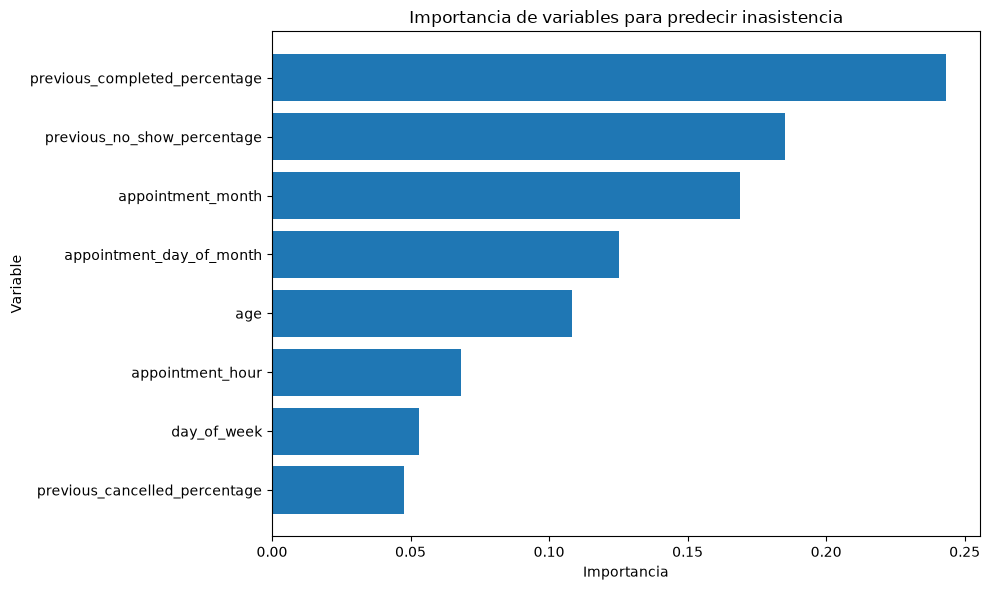

In [5]:
# ==========================================
# IMPORTANCIA DE VARIABLES
# ==========================================

import matplotlib.pyplot as plt

from sklearn.inspection import (
    permutation_importance,
)


best_model_name = (
    results_table.iloc[0]["modelo"]
)

best_model = trained_models[
    best_model_name
]["model"]


# Importancia interna del bosque aleatorio
feature_importance = pd.DataFrame(
    {
        "variable":
            FEATURE_COLUMNS,

        "importancia_modelo":
            best_model.feature_importances_,
    }
).sort_values(
    by="importancia_modelo",
    ascending=False,
).reset_index(
    drop=True,
)


print("=" * 60)
print("IMPORTANCIA INTERNA DEL MODELO")
print("=" * 60)

display(
    feature_importance.round(4)
)


# Importancia por permutación sobre datos de prueba
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,

    scoring="f1",

    n_repeats=20,

    random_state=42,

    n_jobs=-1,
)


permutation_table = pd.DataFrame(
    {
        "variable":
            FEATURE_COLUMNS,

        "importancia_permutacion":
            permutation_result
            .importances_mean,

        "desviacion":
            permutation_result
            .importances_std,
    }
).sort_values(
    by="importancia_permutacion",
    ascending=False,
).reset_index(
    drop=True,
)


print("=" * 60)
print("IMPORTANCIA POR PERMUTACIÓN")
print("=" * 60)

display(
    permutation_table.round(4)
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(
    feature_importance[
        "variable"
    ][::-1],

    feature_importance[
        "importancia_modelo"
    ][::-1],
)

plt.xlabel(
    "Importancia"
)

plt.ylabel(
    "Variable"
)

plt.title(
    "Importancia de variables para predecir inasistencia"
)

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# COMPARACIÓN DE CONJUNTOS DE VARIABLES
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


FEATURE_GROUPS = {
    # Modelo actual con las 8 variables
    "todas_las_variables": [
        "age",
        "appointment_month",
        "appointment_day_of_month",
        "day_of_week",
        "appointment_hour",
        "previous_completed_percentage",
        "previous_no_show_percentage",
        "previous_cancelled_percentage",
    ],

    # Variables indicadas por el profesor
    # más los porcentajes históricos
    "profesor_y_porcentajes": [
        "age",
        "appointment_month",
        "appointment_day_of_month",
        "previous_completed_percentage",
        "previous_no_show_percentage",
        "previous_cancelled_percentage",
    ],

    # Se elimina cancelación porque los tres porcentajes
    # son redundantes y normalmente suman 100
    "sin_porcentaje_cancelaciones": [
        "age",
        "appointment_month",
        "appointment_day_of_month",
        "previous_completed_percentage",
        "previous_no_show_percentage",
    ],

    # Solo las variables con mayor importancia observada
    "variables_mas_importantes": [
        "appointment_month",
        "appointment_day_of_month",
        "previous_completed_percentage",
        "previous_no_show_percentage",
    ],
}


comparison_results = []


for group_name, selected_features in FEATURE_GROUPS.items():
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        X_train[selected_features],
        y_train,
    )

    predicted_classes = model.predict(
        X_test[selected_features]
    )

    predicted_probabilities = model.predict_proba(
        X_test[selected_features]
    )[:, 1]

    result = {
        "grupo":
            group_name,

        "numero_variables":
            len(selected_features),

        "variables":
            ", ".join(selected_features),

        "accuracy":
            accuracy_score(
                y_test,
                predicted_classes,
            ),

        "precision_inasistencia":
            precision_score(
                y_test,
                predicted_classes,
                zero_division=0,
            ),

        "recall_inasistencia":
            recall_score(
                y_test,
                predicted_classes,
                zero_division=0,
            ),

        "f1_inasistencia":
            f1_score(
                y_test,
                predicted_classes,
                zero_division=0,
            ),

        "roc_auc":
            roc_auc_score(
                y_test,
                predicted_probabilities,
            ),
    }

    comparison_results.append(
        result
    )

    print("=" * 60)
    print("GRUPO:", group_name)
    print("Variables:", selected_features)
    print("Matriz de confusión:")
    print(
        confusion_matrix(
            y_test,
            predicted_classes,
        )
    )


feature_group_comparison = (
    pd.DataFrame(
        comparison_results
    )
    .sort_values(
        by=[
            "f1_inasistencia",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("=" * 60)
print("COMPARACIÓN FINAL")
print("=" * 60)

display(
    feature_group_comparison[
        [
            "grupo",
            "numero_variables",
            "accuracy",
            "precision_inasistencia",
            "recall_inasistencia",
            "f1_inasistencia",
            "roc_auc",
        ]
    ].round(4)
)

GRUPO: todas_las_variables
Variables: ['age', 'appointment_month', 'appointment_day_of_month', 'day_of_week', 'appointment_hour', 'previous_completed_percentage', 'previous_no_show_percentage', 'previous_cancelled_percentage']
Matriz de confusión:
[[201  29]
 [ 26  46]]
GRUPO: profesor_y_porcentajes
Variables: ['age', 'appointment_month', 'appointment_day_of_month', 'previous_completed_percentage', 'previous_no_show_percentage', 'previous_cancelled_percentage']
Matriz de confusión:
[[196  34]
 [ 20  52]]
GRUPO: sin_porcentaje_cancelaciones
Variables: ['age', 'appointment_month', 'appointment_day_of_month', 'previous_completed_percentage', 'previous_no_show_percentage']
Matriz de confusión:
[[196  34]
 [ 21  51]]
GRUPO: variables_mas_importantes
Variables: ['appointment_month', 'appointment_day_of_month', 'previous_completed_percentage', 'previous_no_show_percentage']
Matriz de confusión:
[[195  35]
 [ 12  60]]
COMPARACIÓN FINAL


,grupo,numero_variables,accuracy,precision_inasistencia,recall_inasistencia,f1_inasistencia,roc_auc
0,variables_mas_importantes,4,0.8444,0.6316,0.8333,0.7186,0.9143
1,profesor_y_porcentajes,6,0.8212,0.6047,0.7222,0.6582,0.8926
2,sin_porcentaje_cancelaciones,5,0.8179,0.6000,0.7083,0.6497,0.8907
3,todas_las_variables,8,0.8179,0.6133,0.6389,0.6259,0.8740


In [7]:
# ==========================================
# VALIDACIÓN CRUZADA DE LOS GRUPOS
# ==========================================

import numpy as np
import pandas as pd

from sklearn.ensemble import (
    RandomForestClassifier,
)

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_validate,
)


cross_validation = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


scoring = {
    "accuracy":
        make_scorer(
            accuracy_score
        ),

    "precision_inasistencia":
        make_scorer(
            precision_score,
            pos_label=1,
            zero_division=0,
        ),

    "recall_inasistencia":
        make_scorer(
            recall_score,
            pos_label=1,
            zero_division=0,
        ),

    "f1_inasistencia":
        make_scorer(
            f1_score,
            pos_label=1,
            zero_division=0,
        ),

    "roc_auc":
        "roc_auc",
}


cross_validation_results = []


for group_name, selected_features in FEATURE_GROUPS.items():
    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,

        class_weight=
            "balanced_subsample",

        random_state=42,
        n_jobs=-1,
    )

    scores = cross_validate(
        model,

        X[
            selected_features
        ],

        y,

        groups=groups,

        cv=cross_validation,

        scoring=scoring,

        n_jobs=-1,

        return_train_score=False,
    )

    cross_validation_results.append(
        {
            "grupo":
                group_name,

            "numero_variables":
                len(
                    selected_features
                ),

            "accuracy_promedio":
                scores[
                    "test_accuracy"
                ].mean(),

            "precision_promedio":
                scores[
                    "test_precision_inasistencia"
                ].mean(),

            "recall_promedio":
                scores[
                    "test_recall_inasistencia"
                ].mean(),

            "f1_promedio":
                scores[
                    "test_f1_inasistencia"
                ].mean(),

            "f1_desviacion":
                scores[
                    "test_f1_inasistencia"
                ].std(),

            "roc_auc_promedio":
                scores[
                    "test_roc_auc"
                ].mean(),

            "roc_auc_desviacion":
                scores[
                    "test_roc_auc"
                ].std(),
        }
    )


cross_validation_table = (
    pd.DataFrame(
        cross_validation_results
    )
    .sort_values(
        by=[
            "f1_promedio",
            "roc_auc_promedio",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


print("=" * 70)
print("VALIDACIÓN CRUZADA POR PACIENTE")
print("=" * 70)


display(
    cross_validation_table.round(
        4
    )
)

VALIDACIÓN CRUZADA POR PACIENTE


,grupo,numero_variables,accuracy_promedio,precision_promedio,recall_promedio,f1_promedio,f1_desviacion,roc_auc_promedio,roc_auc_desviacion
0,variables_mas_importantes,4,0.8068,0.5337,0.7974,0.6394,0.0158,0.8940,0.0144
1,profesor_y_porcentajes,6,0.8000,0.5269,0.6569,0.5841,0.0435,0.8677,0.0208
2,sin_porcentaje_cancelaciones,5,0.7975,0.5225,0.6456,0.5770,0.0451,0.8685,0.0172
3,todas_las_variables,8,0.7917,0.5148,0.5523,0.5323,0.0290,0.8438,0.0167


In [8]:
# ==========================================
# MODELO DEFINITIVO DE INASISTENCIA
# ==========================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


FINAL_FEATURE_COLUMNS = [
    "age",
    "appointment_month",
    "appointment_day_of_month",
    "previous_completed_percentage",
    "previous_no_show_percentage",
    "previous_cancelled_percentage",
]


final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)


final_model.fit(
    X_train[
        FINAL_FEATURE_COLUMNS
    ],
    y_train,
)


final_predictions = final_model.predict(
    X_test[
        FINAL_FEATURE_COLUMNS
    ]
)


final_probabilities = (
    final_model.predict_proba(
        X_test[
            FINAL_FEATURE_COLUMNS
        ]
    )[:, 1]
)


final_accuracy = accuracy_score(
    y_test,
    final_predictions,
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0,
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0,
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0,
)

final_roc_auc = roc_auc_score(
    y_test,
    final_probabilities,
)


print("=" * 60)
print("MODELO DEFINITIVO")
print("=" * 60)

print(
    "Variables utilizadas:"
)

for feature in FINAL_FEATURE_COLUMNS:
    print("-", feature)


print(
    "\nMatriz de confusión:"
)

print(
    confusion_matrix(
        y_test,
        final_predictions,
    )
)


print(
    "\nReporte de clasificación:"
)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Sí asistió",
            "No asistió",
        ],
        digits=4,
        zero_division=0,
    )
)


print(
    "Accuracy:",
    round(
        final_accuracy,
        4,
    ),
)

print(
    "Precisión de inasistencia:",
    round(
        final_precision,
        4,
    ),
)

print(
    "Recall de inasistencia:",
    round(
        final_recall,
        4,
    ),
)

print(
    "F1 de inasistencia:",
    round(
        final_f1,
        4,
    ),
)

print(
    "ROC AUC:",
    round(
        final_roc_auc,
        4,
    ),
)

MODELO DEFINITIVO
Variables utilizadas:
- age
- appointment_month
- appointment_day_of_month
- previous_completed_percentage
- previous_no_show_percentage
- previous_cancelled_percentage

Matriz de confusión:
[[196  34]
 [ 20  52]]

Reporte de clasificación:
              precision    recall  f1-score   support

  Sí asistió     0.9074    0.8522    0.8789       230
  No asistió     0.6047    0.7222    0.6582        72

    accuracy                         0.8212       302
   macro avg     0.7560    0.7872    0.7686       302
weighted avg     0.8352    0.8212    0.8263       302

Accuracy: 0.8212
Precisión de inasistencia: 0.6047
Recall de inasistencia: 0.7222
F1 de inasistencia: 0.6582
ROC AUC: 0.8926


In [9]:
# ==========================================
# GUARDAR MODELO DEFINITIVO
# ==========================================

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd


OUTPUT_DIR = Path.cwd()

NEW_MODEL_PATH = (
    OUTPUT_DIR
    / "modelo_inasistencia_actualizado.joblib"
)

METRICS_PATH = (
    OUTPUT_DIR
    / "metricas_asistencia_actualizadas.json"
)

IMPORTANCE_PATH = (
    OUTPUT_DIR
    / "importancia_variables_asistencia_actualizada.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "predicciones_prueba_asistencia_actualizada.csv"
)


# Importancia de variables
final_feature_importance = (
    pd.DataFrame(
        {
            "variable":
                FINAL_FEATURE_COLUMNS,

            "importancia":
                final_model.feature_importances_,
        }
    )
    .sort_values(
        by="importancia",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# Paquete del modelo
model_package = {
    "model":
        final_model,

    "model_name":
        "bosque_aleatorio",

    "feature_columns":
        FINAL_FEATURE_COLUMNS,

    "target_column":
        "inasistencia_cita",

    "positive_class":
        {
            "value": 1,
            "meaning":
                "El paciente no asistió a la cita",
        },

    "negative_class":
        {
            "value": 0,
            "meaning":
                "El paciente sí asistió a la cita",
        },

    "metrics":
        {
            "accuracy":
                float(final_accuracy),

            "precision_inasistencia":
                float(final_precision),

            "recall_inasistencia":
                float(final_recall),

            "f1_inasistencia":
                float(final_f1),

            "roc_auc":
                float(final_roc_auc),
        },

    "trained_at_utc":
        pd.Timestamp.now(
            tz="UTC"
        ).isoformat(),

    "random_state":
        42,
}


joblib.dump(
    model_package,
    NEW_MODEL_PATH,
)


# Guardar métricas
with METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as metrics_file:
    json.dump(
        model_package["metrics"],
        metrics_file,
        ensure_ascii=False,
        indent=4,
    )


# Guardar importancia
final_feature_importance.to_csv(
    IMPORTANCE_PATH,
    index=False,
)


# Guardar predicciones del conjunto de prueba
test_predictions = clean_data.iloc[
    test_index
][
    [
        "appointment_id",
        "patient_id",
        "appointment_date",
        "inasistencia_cita",
    ]
].copy()


test_predictions[
    "inasistencia_predicha"
] = final_predictions


test_predictions[
    "probabilidad_inasistencia"
] = final_probabilities


test_predictions[
    "prediccion_correcta"
] = (
    test_predictions[
        "inasistencia_cita"
    ]
    ==
    test_predictions[
        "inasistencia_predicha"
    ]
)


test_predictions.to_csv(
    PREDICTIONS_PATH,
    index=False,
)


print("=" * 60)
print("ARCHIVOS GUARDADOS")
print("=" * 60)

print(
    "Modelo:",
    NEW_MODEL_PATH,
)

print(
    "Métricas:",
    METRICS_PATH,
)

print(
    "Importancia:",
    IMPORTANCE_PATH,
)

print(
    "Predicciones:",
    PREDICTIONS_PATH,
)

print(
    "\nVariables guardadas en el modelo:"
)

for feature in model_package[
    "feature_columns"
]:
    print("-", feature)

ARCHIVOS GUARDADOS
Modelo: C:\Users\rmera\Downloads\RubiRamos-ML-API\ML\modelo_inasistencia_actualizado.joblib
Métricas: C:\Users\rmera\Downloads\RubiRamos-ML-API\ML\metricas_asistencia_actualizadas.json
Importancia: C:\Users\rmera\Downloads\RubiRamos-ML-API\ML\importancia_variables_asistencia_actualizada.csv
Predicciones: C:\Users\rmera\Downloads\RubiRamos-ML-API\ML\predicciones_prueba_asistencia_actualizada.csv

Variables guardadas en el modelo:
- age
- appointment_month
- appointment_day_of_month
- previous_completed_percentage
- previous_no_show_percentage
- previous_cancelled_percentage
